In [12]:
import pdfplumber
import pandas as pd

PDF_PATH = r"D:\PC DISAINE\toky\Perso-D\red\momo\transaction-history-20260721_133521269.pdf"  # change to your file path

all_tables = []

with pdfplumber.open(PDF_PATH) as pdf:
    for i, page in enumerate(pdf.pages):
        table = page.extract_table()
        if table:
            print(f"Page {i+1}: found table with {len(table)-1} rows")
            all_tables.append(table)

# Use first table found, or merge all
raw = all_tables[0]
df = pd.DataFrame(raw[1:], columns=raw[0])  # row 0 = headers
df.head()

Page 1: found table with 13 rows
Page 2: found table with 16 rows
Page 3: found table with 9 rows


,Transaction\nId,Status,Transaction Type,Date,From,To,Amount (RWF),Fee\n(RWF),Balance\nAfter\n(RWF)
0,29327649933,SUCCESSFUL,PAYMENT,2026-07-20 21:43:01,250788787497\nJovani NTABGOBA,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,5000,N/A,400607
1,29326723839,SUCCESSFUL,PAYMENT,2026-07-20 20:48:50,250788300271\nSakindi Evode\nHABAMENSHI,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,3000,N/A,395632
2,29326635354,SUCCESSFUL,PAYMENT,2026-07-20 20:46:06,250795620926\nPapukim MANZI,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,5500,N/A,392647
3,29325786435,SUCCESSFUL,PAYMENT,2026-07-20 20:09:20,250788359997\nJohnny KAYIHURA,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,3000,N/A,387174
4,29323568497,SUCCESSFUL,PAYMENT,2026-07-20 18:57:55,250788325406\nJean De Dieu\nUWIHAYE,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,5500,N/A,384189


# Clean raw tabular data

In [13]:
headers = all_tables[0][0]
frames = []

for t in all_tables:
    rows = [row for row in t if row != headers]  # drop repeated header rows
    frames.append(pd.DataFrame(rows, columns=headers))

df = pd.concat(frames, ignore_index=True)

df = df.replace("", pd.NA)
df = df.dropna(how="any")

df = df.rename(columns={'Amount\n(RWF)': 'Amount (RWF)'})

df['Amount (RWF)'] = df['Amount (RWF)'].astype(int)

df.shape

(37, 9)

In [14]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d %H:%M:%S")
start = pd.to_datetime("2026-07-20 00:00:00")
end   = pd.to_datetime("2026-07-20 23:59:59")

df_subset = df[(df["Date"] >= start) & (df["Date"] <= end)]
df_subset.shape

(31, 9)

# Calculate the sum of all transactions

In [15]:
# Assign +/- sign based on the type column
df_subset["Signed Amount"] = df_subset["Amount (RWF)"].where(df_subset["Transaction Type"] == "PAYMENT", -df_subset["Amount (RWF)"])

# Then sum
total_transactions = df_subset["Signed Amount"].sum()
print(total_transactions)

202800


## Total fees

In [16]:
balance_2026_06_18 = 214690
balance_2026_06_19 = 400607

total_actual_transactions = balance_2026_06_19 - balance_2026_06_18
print(total_actual_transactions)

185917


In [23]:
error = 16000
total_fees = total_transactions - total_actual_transactions - error

print(total_fees)

883


# Check individual transaction fee

In [24]:
df_subset = df_subset.rename(columns={'Balance\nAfter\n(RWF)': 'Balance'})
df_subset["Balance"] = df_subset["Balance"].astype("int")

In [25]:
df_subset["transaction_fee"] = df_subset["Amount (RWF)"] - ( df_subset["Balance"] - df_subset["Balance"].shift(-1) )


In [26]:
total = df_subset.loc[(df_subset["transaction_fee"] >= 0) & (df_subset["transaction_fee"] <= 3000), "transaction_fee"].sum()
print(total)

0.0


In [21]:
df_subset

,Transaction\nId,Status,Transaction Type,Date,From,To,Amount (RWF),Fee\n(RWF),Balance,Signed Amount,transaction_fee
0,29327649933,SUCCESSFUL,PAYMENT,2026-07-20 21:43:01,250788787497\nJovani NTABGOBA,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,5000,N/A,400607,5000,25.0
1,29326723839,SUCCESSFUL,PAYMENT,2026-07-20 20:48:50,250788300271\nSakindi Evode\nHABAMENSHI,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,3000,N/A,395632,3000,15.0
2,29326635354,SUCCESSFUL,PAYMENT,2026-07-20 20:46:06,250795620926\nPapukim MANZI,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,5500,N/A,392647,5500,27.0
3,29325786435,SUCCESSFUL,PAYMENT,2026-07-20 20:09:20,250788359997\nJohnny KAYIHURA,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,3000,N/A,387174,3000,15.0
4,29323568497,SUCCESSFUL,PAYMENT,2026-07-20 18:57:55,250788325406\nJean De Dieu\nUWIHAYE,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,5500,N/A,384189,5500,27.0
5,29321118918,SUCCESSFUL,PAYMENT,2026-07-20 17:43:39,250791569945\nShirleen RUBANGURA\nTETA,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,4500,N/A,378716,4500,22.0
6,29320586324,SUCCESSFUL,PAYMENT,2026-07-20 17:23:27,250784584905\nGeoffrey\nRUGENGAMANZI,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,7000,N/A,374238,7000,35.0
7,29319912505,SUCCESSFUL,PAYMENT,2026-07-20 16:54:46,250787389658\nAbedi RWANGATO,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,5000,N/A,367273,5000,25.0
8,29319770889,SUCCESSFUL,PAYMENT,2026-07-20 16:48:32,250798694605\nBOUMENDIL JEROME\nROGER,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,6500,N/A,362298,6500,32.0
9,29319378697,SUCCESSFUL,PAYMENT,2026-07-20 16:30:11,250795033116\nKARIMPOUR SAYA,38998332\nRED IKIRWA\nFLAVOURS Ltd\nRED IKIRWA...,12000,N/A,355830,12000,60.0


# Check the wallet movement

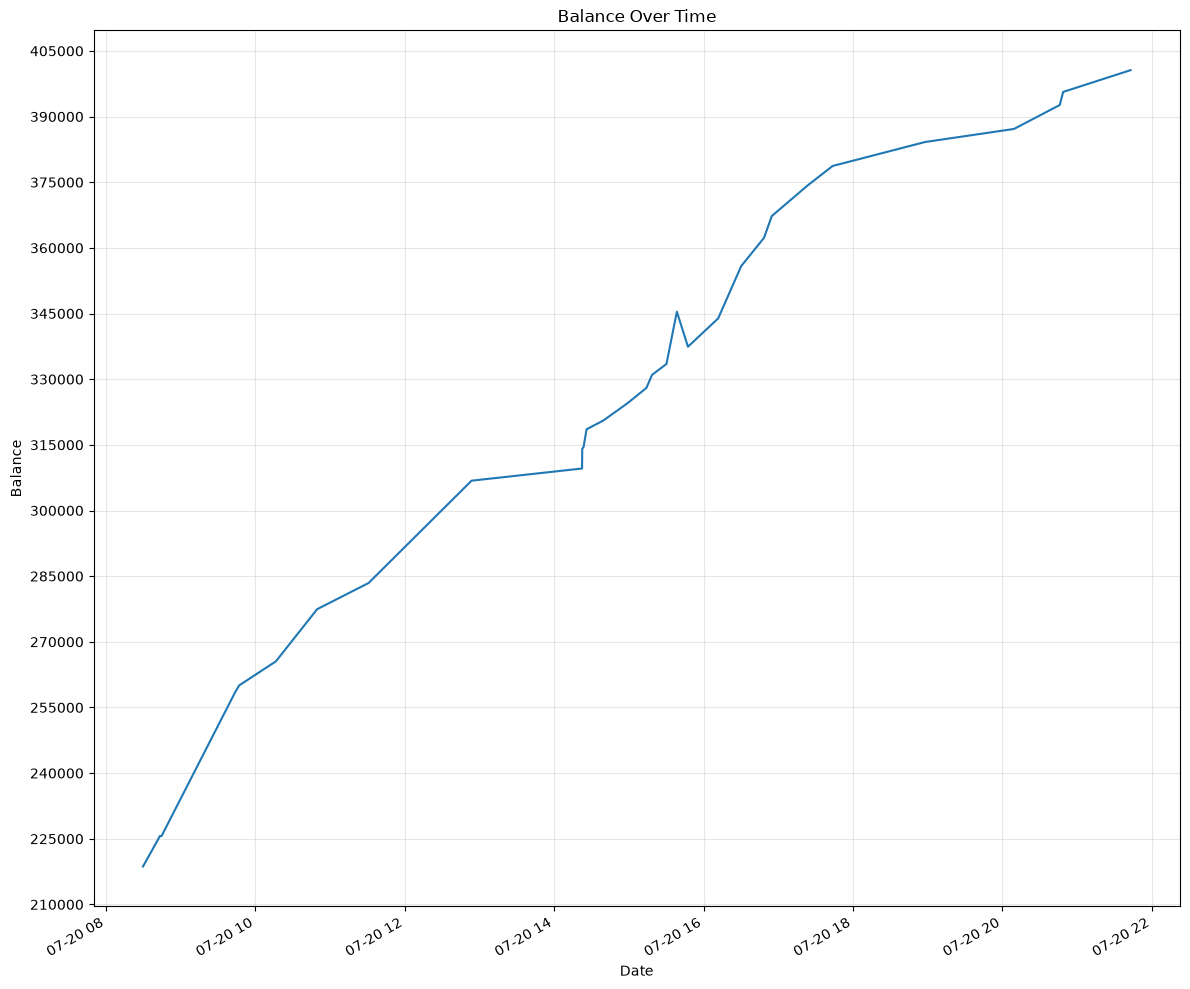

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# Convert the date column to datetime (adjust 'Date' to your actual column name)
df_subset['Date'] = pd.to_datetime(df_subset['Date'])

# Sort by date so the line plots in chronological order
df_subset = df_subset.sort_values('Date')

plt.figure(figsize=(12, 10))
plt.plot(df_subset['Date'], df_subset['Balance'])
plt.title('Balance Over Time')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.grid(True, alpha=0.3)

plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=20))

plt.gcf().autofmt_xdate()  # rotates and aligns the date labels nicely
plt.tight_layout()
plt.show()